Applying Tversky transformations to environmental audio

In [1]:
# imports
from pyha_analyzer import extractors
from pyha_analyzer.preprocessors import MelSpectrogramPreprocessorsNew
import torch
from datetime import datetime


import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.models as torchmodels 


from torchvision.utils import make_grid

from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt

In [2]:
config = {
    "learning_rate": 10e-3,
    "learning_rate_decay": 0.001,
    "device": 'cuda',
    "latent_dim": 10,
    "percept": False,
    "seed": 1
}

config["save_path"] = "model_dim_" + str(config["latent_dim"]) + ".pt"

In [3]:
torch.manual_seed(config["seed"])

In [4]:
# extract our data
coralreef_extractor = extractors.MultiCoralReef()
coral_ads = coralreef_extractor('/home/a.jajodia.229/acoustic/local_data/coral')


preprocessor = MelSpectrogramPreprocessorsNew(duration=5, class_list=coral_ads["train"].features["labels"].feature.names)



coral_ads["train"].set_transform(preprocessor)

min size is 15538 from dataset Paola
sampling 15538 from (Paola, 0)
sampling 15538 from (Paola, 1)
sampling 1294 from (Williams_et_al_2024, 0)
sampling 1294 from (Williams_et_al_2024, 1)
Loaded: 33664 samples


Casting the dataset:   0%|          | 0/23564 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/3030 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/7070 [00:00<?, ? examples/s]

In [5]:
class Reshape(nn.Module):
    def __init__(self, *shape):
        super(Reshape, self).__init__()
        self.shape = shape

    def forward(self, x):
        return x.reshape(x.shape[0], *self.shape)

In [6]:
class Tversky(nn.Module):
    """
    Similar to a fully-connected layer, but computes Tversky similarity instead
    """
    def __init__(
        self,
        in_features: tuple,
        out_features: int,
        num_features=256,
        feature_bank=None,
        phi=torch.mul,
        substract=True,
        device=None,
        dtype=None
    ) -> None:
        factory_kwargs = {"device": device, "dtype": dtype}
        super().__init__()
        
        self.phi = phi
        self.substract = substract
        
        if feature_bank is None:
            self.feature_bank = nn.Parameter(
                torch.empty((num_features,) + in_features, **factory_kwargs)
            )
        else:
            self.feature_bank = feature_bank
            
        self.prototypes = nn.Parameter(
                torch.empty( (out_features,) + in_features, **factory_kwargs)
            )
            
        self.alpha = nn.Parameter(torch.empty(1))
        self.beta = nn.Parameter(torch.empty(1))
        self.theta = nn.Parameter(torch.empty(1))

        self.reset_parameters()
        
    def reset_parameters(self) -> None:
        nn.init.uniform_(self.feature_bank)
        nn.init.uniform_(self.prototypes)
        nn.init.uniform_(self.alpha)
        nn.init.uniform_(self.beta)
        nn.init.uniform_(self.theta)
    
    def forward(self, input: torch.Tensor):
        
        a_f = (input.flatten(1, -1).unsqueeze(1) * self.feature_bank.flatten(1, -1).unsqueeze(0)).sum(-1).unsqueeze(1)
        p_f = (self.prototypes.flatten(1, -1).unsqueeze(1) * self.feature_bank.flatten(1, -1).unsqueeze(0)).sum(-1).unsqueeze(0)
        

        val = self.phi(a_f, p_f)
        mask = (torch.minimum(a_f, p_f) >= 0).int()
        intersection = self.theta * (val * mask).sum(-1)
        
        
        if self.substract:
            alpha_difference = -self.alpha * (a_f * ((a_f > 0) | (p_f <= 0)).int()).sum(-1)
            beta_difference = -self.beta * (p_f * ((p_f > 0) | (a_f <= 0)).int()).sum(-1)
        else:
            alpha_difference = -self.alpha * ((a_f - p_f) * ((a_f > 0) | (p_f > 0) | (a_f > p_f)).int()).sum(-1)
            beta_difference = -self.beta * ((p_f - a_f) * ((p_f > 0) | (a_f > 0) | (p_f > a_f)).int()).sum(-1)
        
        return intersection + alpha_difference + beta_difference
    
t = Tversky((4,), 10, 5)

A = torch.rand((2, 4))

t(A).shape

torch.Size([2, 10])

In [7]:
VGG = torchmodels.vgg16(weights=torchmodels.VGG16_Weights.DEFAULT).features[:13]
for nm, mod in VGG.named_modules():
    if isinstance(mod, nn.MaxPool2d):
        setattr(VGG, nm,  nn.AvgPool2d(2 ,2))
VGG.eval().to(config["device"])

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

In [8]:
encoder = lambda nfeat : nn.Sequential(
    nn.Conv2d(1, 32, 3, stride=2, bias=False, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(True),
    nn.Conv2d(32, 64, 3, stride=2, bias=False, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(True),
    nn.Conv2d(64, 128, 3, stride=2, bias=False, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(True),
    nn.Conv2d(128, 256, 3, stride=2, bias=False, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(True),
    nn.Conv2d(256, 512, 3, stride=2, bias=False, padding=1),
    nn.BatchNorm2d(512),
    nn.ReLU(True),
    nn.Conv2d(512, nfeat, 3, stride=2, padding=1),
    
    nn.Flatten()
)

decoder = lambda nfeat : nn.Sequential(
    Reshape(nfeat, 4, 4),
    nn.ReLU(True),
    
    nn.Upsample(scale_factor=2),
    nn.Conv2d(nfeat, 512, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(512),
    nn.ReLU(True),
    nn.Conv2d(512, 512, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(512),
    nn.ReLU(True),
    
    nn.Upsample(scale_factor=2),
    nn.Conv2d(512, 256, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(True),
    nn.Conv2d(256, 256, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(True),

    nn.Upsample(scale_factor=2),
    nn.Conv2d(256, 128, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(True),
    nn.Conv2d(128, 128, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(True),

    nn.Upsample(scale_factor=2),
    nn.Conv2d(128, 64, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(True),
    nn.Conv2d(64, 64, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(True),

    nn.Upsample(scale_factor=2),
    nn.Conv2d(64, 32, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(True),
    nn.Conv2d(32, 32, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(True),

    nn.Upsample(scale_factor=2),
    nn.Conv2d(32, 1, (3, 3), bias=False, padding=1),
    nn.BatchNorm2d(1),
    nn.ReLU(True),
    nn.Conv2d(1, 1, (3, 3), bias=False, padding=1)
)

encoder = encoder(config['latent_dim'])
decoder = decoder(config['latent_dim'])

model = nn.Sequential(
    encoder,
    Tversky((config['latent_dim'] * (4**2),), config['latent_dim'] * (4**2)),
    decoder
).to(config['device'])

0:   0%|          | 0/2946 [00:00<?, ?it/s]

0.07348524346236832


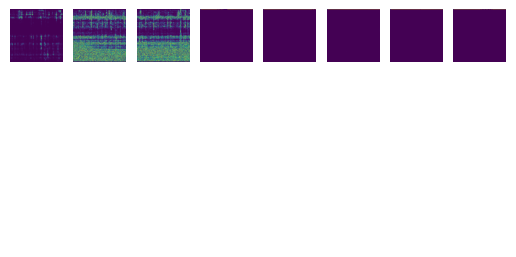

0.04741506301210734


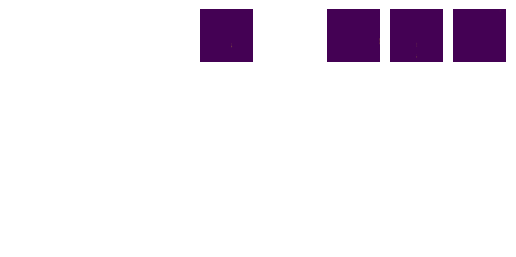

0.04950267926278886


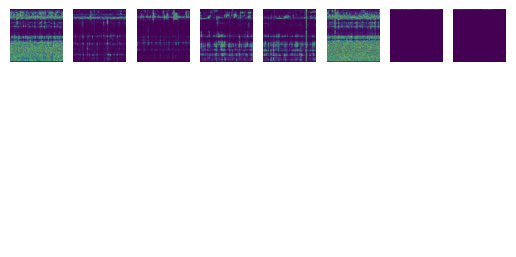

Exception ignored from cffi callback <function SoundFile._init_virtual_io.<locals>.vio_read at 0x7dee416aa5c0>:
Traceback (most recent call last):
  File "/home/a.jajodia.229/acoustic/anu_experiments_acoustic_species/.venv/lib/python3.11/site-packages/soundfile.py", line 1295, in vio_read
    data_read = file.readinto(buf)
                ^^

KeyboardInterrupt: 

^^^^^^^^^^^^

^^^^
KeyboardInterrupt: 


In [32]:
step, loss = 0, []

for epoch in range(1):
    for data in tqdm(train_loader, desc=str(epoch), leave=False):

        x = data['audio']
        
        
        optimizer.zero_grad()
        label = x.to(config["device"])[..., :256]
        
        zeroes_index = (torch.sum(label, dim=0) != 0)
        
        
        x = encoder(label)
        
        pred = decoder(x)
        
        if config['percept'] == True:
            label_vgg = VGG(label.expand(label.shape[0], 3, *label.shape[2:]))
            pred_vgg = VGG(pred.expand(pred.shape[0], 3, *pred.shape[2:]))
            
            score = metric(label_vgg, pred_vgg)
        

        else:
            score = metric(label, pred)
        score.backward()
        optimizer.step()
        
        loss.append(score.item())
        # print(datetime.now())

        # if len(loss) > 2000 and np.median(loss[-2000:-1000]) < np.median(loss[-1000:]):
        #     print('Early stop')
        #     torch.save(model.state_dict(), config["save_path"])
        #     break

        step += 1

        if step % 500 == 0: # scheduler
            scheduler.step()
            
        #     print(score)

        # Plot images
        if step % 250 == 0 :
            
            print(np.mean(loss[-250: step]))
            
            # Plot reconstructions
            label_images = [(e-e.min())/(e.max()-e.min()) for e in label[:8].detach().cpu().squeeze()]
            pred_images = [(e-e.min())/(e.max()-e.min()) for e in pred[:8].detach().cpu().squeeze()]
            
            images = np.array([label_images, pred_images])
            
            f, axarr = plt.subplots(2,8)
            plt.subplots_adjust(hspace=0)
            for i in range(2):
                for j in range(8):
                    axarr[i,j].imshow(images[i,j])
                    axarr[i,j].set_axis_off()
            plt.show()
            plt.close()

In [ ]:
pred

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

In [11]:
torch.save(model.state_dict(), "tversky_auto_model.pt")

In [31]:
model.load_state_dict(torch.load("tversky_auto_model.pt"))
model.eval().to(config["device"])

Sequential(
  (0): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, affin

In [15]:
torch.load("tversky_auto_model.pt").keys()

odict_keys(['0.0.weight', '0.1.weight', '0.1.bias', '0.1.running_mean', '0.1.running_var', '0.1.num_batches_tracked', '0.3.weight', '0.4.weight', '0.4.bias', '0.4.running_mean', '0.4.running_var', '0.4.num_batches_tracked', '0.6.weight', '0.7.weight', '0.7.bias', '0.7.running_mean', '0.7.running_var', '0.7.num_batches_tracked', '0.9.weight', '0.10.weight', '0.10.bias', '0.10.running_mean', '0.10.running_var', '0.10.num_batches_tracked', '0.12.weight', '0.13.weight', '0.13.bias', '0.13.running_mean', '0.13.running_var', '0.13.num_batches_tracked', '0.15.weight', '0.15.bias', '1.feature_bank', '1.prototypes', '1.alpha', '1.beta', '1.theta', '2.3.weight', '2.4.weight', '2.4.bias', '2.4.running_mean', '2.4.running_var', '2.4.num_batches_tracked', '2.6.weight', '2.7.weight', '2.7.bias', '2.7.running_mean', '2.7.running_var', '2.7.num_batches_tracked', '2.10.weight', '2.11.weight', '2.11.bias', '2.11.running_mean', '2.11.running_var', '2.11.num_batches_tracked', '2.13.weight', '2.14.weight',

In [24]:
prototype_list = decoder(torch.load("tversky_auto_model.pt")['1.prototypes']).detach().cpu()
feature_list = decoder(torch.load("tversky_auto_model.pt")['1.feature_bank']).detach().cpu()

In [28]:
normalize = lambda e: (e-e.min())/(e.max()-e.min())

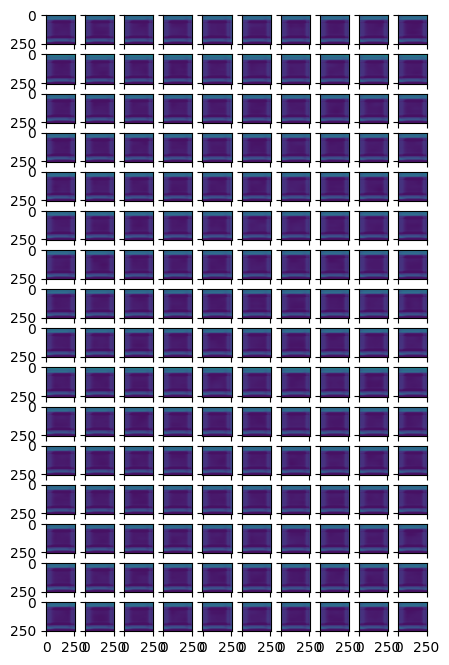

In [ ]:
# get the prototype images
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
import matplotlib.image as mpimg


fig = plt.figure(figsize=(8., 8.))
grid = ImageGrid(fig, 111, nrows_ncols=(16, 10), axes_pad=0.1)

for ax, im in zip(grid, feature_list):
    ax.imshow(normalize(im.squeeze()))

plt.show()